# Deforestation data: tree cover loss in tropical countries, 2001 to 2025

**Research question:** do commodity price booms (soy, palm oil, beef) cause deforestation, and is this
effect weaker in countries with better governance?

This notebook prepares and explores our outcome variable. It follows the steps of the course recipe:
1. Select our ingredients: load the Global Forest Watch country statistics and build a country-year panel
2. Pick the right quantity: define the sample of tropical countries
3. Taste the ingredients: build the tree cover loss rate, check data quality and extreme values
4. Analyse the drivers of tree cover loss and build an agricultural loss rate

*Data: Hansen et al. (2013) / Global Forest Watch, country statistics (canopy density threshold 30%);
Natural Earth country borders. Packages needed beyond the course ones: `country_converter`, `geopandas`.*

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'

## 1. Data preparation

### 1.1 Load the Global Forest Watch file

In [2]:
BASE_URL = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/"
xls = pd.ExcelFile(BASE_URL + "raw/forest/global.xlsx")
print(xls.sheet_names)

['ReadMe', 'Country tree cover loss', 'Country primary loss', 'Country drivers', 'Country primary drivers', 'Country carbon data', 'Subnational 1 tree cover loss', 'Subnational 1 primary loss', 'Subnational 1 drivers', 'Subnational 1 primary drivers', 'Subnational 1 carbon data']


In [3]:
df_gfw = pd.read_excel(xls, sheet_name="Country tree cover loss")
print(df_gfw.shape)
print(df_gfw.columns.tolist()) #transform columns in a list
df_gfw.head()


(1880, 30)
['country', 'threshold', 'area_ha', 'extent_2000_ha', 'extent_2010_ha', 'tc_loss_ha_2001', 'tc_loss_ha_2002', 'tc_loss_ha_2003', 'tc_loss_ha_2004', 'tc_loss_ha_2005', 'tc_loss_ha_2006', 'tc_loss_ha_2007', 'tc_loss_ha_2008', 'tc_loss_ha_2009', 'tc_loss_ha_2010', 'tc_loss_ha_2011', 'tc_loss_ha_2012', 'tc_loss_ha_2013', 'tc_loss_ha_2014', 'tc_loss_ha_2015', 'tc_loss_ha_2016', 'tc_loss_ha_2017', 'tc_loss_ha_2018', 'tc_loss_ha_2019', 'tc_loss_ha_2020', 'tc_loss_ha_2021', 'tc_loss_ha_2022', 'tc_loss_ha_2023', 'tc_loss_ha_2024', 'tc_loss_ha_2025']


,country,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
0,Afghanistan,0,64383655,64383655,64383655,103,214,267,225,268,...,0,0,32,26,46,47,15,133,223,203
1,Afghanistan,10,64383655,432070,126231,92,190,254,207,246,...,0,0,28,19,40,37,9,32,32,19
2,Afghanistan,15,64383655,302629,106851,91,186,247,205,240,...,0,0,28,18,39,32,8,22,17,12
3,Afghanistan,20,64383655,284331,105718,89,181,245,202,238,...,0,0,28,18,39,32,8,22,17,11
4,Afghanistan,25,64383655,254843,72384,89,180,245,202,237,...,0,0,27,18,38,28,7,20,14,11


### 1.2 First look at the raw data

In [4]:
df_gfw.dtypes

country              str
threshold          int64
area_ha            int64
extent_2000_ha     int64
extent_2010_ha     int64
tc_loss_ha_2001    int64
tc_loss_ha_2002    int64
tc_loss_ha_2003    int64
tc_loss_ha_2004    int64
tc_loss_ha_2005    int64
tc_loss_ha_2006    int64
tc_loss_ha_2007    int64
tc_loss_ha_2008    int64
tc_loss_ha_2009    int64
tc_loss_ha_2010    int64
tc_loss_ha_2011    int64
tc_loss_ha_2012    int64
tc_loss_ha_2013    int64
tc_loss_ha_2014    int64
tc_loss_ha_2015    int64
tc_loss_ha_2016    int64
tc_loss_ha_2017    int64
tc_loss_ha_2018    int64
tc_loss_ha_2019    int64
tc_loss_ha_2020    int64
tc_loss_ha_2021    int64
tc_loss_ha_2022    int64
tc_loss_ha_2023    int64
tc_loss_ha_2024    int64
tc_loss_ha_2025    int64
dtype: object

In [5]:
print("Canopy thresholds:", sorted(df_gfw["threshold"].unique())) #what kind of canopy density thresholds
print("Number of countries:", df_gfw["country"].nunique()) #how many countries
df_gfw["country"].value_counts().head() #how many times does each country appear

Canopy thresholds: [np.int64(0), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(50), np.int64(75)]
Number of countries: 226


country
India                  48
China                  32
Pakistan               16
Afghanistan             8
AkrotiriandDhekelia     8
Name: count, dtype: int64

In [6]:
df_gfw.describe()

,threshold,area_ha,extent_2000_ha,extent_2010_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,tc_loss_ha_2006,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
count,1880.000000,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,...,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03,1.880000e+03
mean,28.125000,5.625871e+07,2.164250e+07,2.133062e+07,5.591612e+04,6.817898e+04,5.993713e+04,8.222903e+04,7.553689e+04,7.359937e+04,...,1.242118e+05,1.237335e+05,1.039086e+05,1.016883e+05,1.098099e+05,1.059017e+05,9.591977e+04,1.192438e+05,1.255662e+05,1.085041e+05
std,22.497302,1.730920e+08,8.991176e+07,8.910878e+07,2.650239e+05,3.487218e+05,3.190679e+05,4.190912e+05,3.589016e+05,3.376519e+05,...,5.481704e+05,5.169386e+05,4.636014e+05,3.910835e+05,4.924874e+05,5.203855e+05,4.171558e+05,6.351250e+05,5.875227e+05,5.143998e+05
min,0.000000,5.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,13.750000,5.719730e+05,1.798775e+04,1.941175e+04,1.800000e+01,9.750000e+00,9.750000e+00,1.000000e+01,1.500000e+01,1.100000e+01,...,1.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,6.000000e+00
50%,22.500000,7.823151e+06,1.095623e+06,1.053650e+06,1.142000e+03,8.940000e+02,8.045000e+02,1.302500e+03,1.307500e+03,1.249500e+03,...,1.632000e+03,2.144000e+03,1.419000e+03,1.381000e+03,1.856500e+03,1.468000e+03,1.208000e+03,1.820000e+03,1.684500e+03,2.258500e+03
75%,35.000000,3.992862e+07,9.378323e+06,9.229888e+06,1.841875e+04,1.925175e+04,1.290850e+04,1.811075e+04,2.044675e+04,2.179800e+04,...,3.231250e+04,4.653350e+04,3.904375e+04,3.856075e+04,3.705000e+04,3.534400e+04,3.572550e+04,3.888200e+04,3.632600e+04,3.358175e+04
max,75.000000,1.689455e+09,1.689455e+09,1.689455e+09,2.933201e+06,3.715945e+06,3.489259e+06,4.133607e+06,3.675952e+06,3.094810e+06,...,6.407238e+06,6.143921e+06,6.621833e+06,4.847067e+06,8.217252e+06,8.559449e+06,5.126743e+06,1.017602e+07,7.421840e+06,6.785882e+06


In [7]:
df_gfw.isna().sum().sort_values(ascending=False).head(10)

country            0
threshold          0
tc_loss_ha_2024    0
tc_loss_ha_2023    0
tc_loss_ha_2022    0
tc_loss_ha_2021    0
tc_loss_ha_2020    0
tc_loss_ha_2019    0
tc_loss_ha_2018    0
tc_loss_ha_2017    0
dtype: int64

### 1.3 Keep the 30% canopy density threshold

In [8]:
df = df_gfw.loc[df_gfw["threshold"] == 30].reset_index(drop=True) #keep only the 30% canopy density threshold (standard of GFW to avoid areas where there is trees but no forest)
print("Rows before:", len(df_gfw), "| rows after:", len(df))
print("Countries: ", df["country"].nunique()) #number of unique countries

Rows before: 1880 | rows after: 235
Countries:  226


### 1.4 Reshape into a country-year panel

In [9]:
loss_cols = [c for c in df.columns if c.startswith("tc_loss_ha_")] #creating columns of loss
df = df.loc[:, ["country", "extent_2000_ha"]+ loss_cols]  #creating new df with country, extent2000 and loss
print("Loss columns:", loss_cols[0], "to", loss_cols[-1])
df.head()

Loss columns: tc_loss_ha_2001 to tc_loss_ha_2025


,country,extent_2000_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,tc_loss_ha_2006,tc_loss_ha_2007,tc_loss_ha_2008,...,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024,tc_loss_ha_2025
0,Afghanistan,205771,88,179,244,201,236,152,253,108,...,0,0,26,17,37,26,6,15,10,9
1,AkrotiriandDhekelia,911,3,1,0,3,0,4,7,3,...,17,3,2,1,1,2,0,0,2,4
2,Albania,648459,3729,889,614,3236,693,962,5222,5470,...,928,1687,2048,1074,1117,1686,2095,2503,889,3825
3,Algeria,1223324,3468,3009,3830,4374,4469,5413,5200,7971,...,8011,45969,5761,6290,13072,20472,13442,22020,4407,4498
4,Andorra,18989,2,1,0,23,2,7,2,5,...,1,3,15,8,27,2,15,6,17,14


In [10]:
df = df.melt(id_vars=["country", "extent_2000_ha"], value_vars=loss_cols, var_name="loss_col", value_name="loss_ha") #melt the columns in one
df["year"] = df["loss_col"].str[-4:].astype(int) #extract the year from the column
df = df.drop(columns="loss_col")

df.head()

,country,extent_2000_ha,loss_ha,year
0,Afghanistan,205771,88,2001
1,AkrotiriandDhekelia,911,3,2001
2,Albania,648459,3729,2001
3,Algeria,1223324,3468,2001
4,Andorra,18989,2,2001


### 1.5 Add ISO3 country codes and merge split countries

In [11]:
import country_converter as coco
import logging
logging.getLogger("country_converter").setLevel(logging.ERROR)

names = df["country"].unique()
# not_found=np.nan so unconverted names become NaN (not_found=None would return the original name)
iso_map = dict(zip(names, coco.convert(list(names), to="ISO3", not_found=np.nan)))
iso_map["UnitedStatesMinorOutlyingIsl"] = "UMI" #coco returns a list ['USA', 'UMI'] for this name, keep the correct one
iso_map["NorthernCyprus"] = "XNC" #no official ISO3 code (coco gives CYP), XNC is a custom code so it stays separate from Cyprus
iso_map["México"] = "MEX" #coco cannot read the accented spelling

not_found = [n for n, iso in iso_map.items() if pd.isna(iso)]
print("Countries without ISO3:", not_found)

df["iso3"] = df["country"].map(iso_map)
df = df.dropna(subset=["iso3"]).reset_index(drop=True)

Countries without ISO3: ['AkrotiriandDhekelia', 'IsleofMan']


In [12]:
# Some countries appear in several rows: China (4), India (6) and Pakistan (2) are split into parts (disputed areas).
# Add them up to get one row per country and year
print("Rows before:", len(df))
df = (df.groupby(["iso3", "year"], as_index=False)
        .agg(country=("country", "first"),
             extent_2000_ha=("extent_2000_ha", "sum"),
             loss_ha=("loss_ha", "sum")))
print("Rows after:", len(df))

Rows before: 5825
Rows after: 5600


### 1.6 Check the final panel

In [13]:
print("Rows:", len(df))
print("Countries:", df['iso3'].nunique())
print("Years:", df['year'].min(), "to", df['year'].max())
print("Duplicated country-years:", df.duplicated(subset=['iso3', 'year']).sum())

# Reorder columns and rows to make the table readable
df = df[['iso3', 'country', 'year', 'extent_2000_ha', 'loss_ha']]
df = df.sort_values(['iso3', 'year']).reset_index(drop=True)
df.head(10)


Rows: 5600
Countries: 224
Years: 2001 to 2025
Duplicated country-years: 0


,iso3,country,year,extent_2000_ha,loss_ha
0,ABW,Aruba,2001,25,0
1,ABW,Aruba,2002,25,1
2,ABW,Aruba,2003,25,1
3,ABW,Aruba,2004,25,0
4,ABW,Aruba,2005,25,0
5,ABW,Aruba,2006,25,0
6,ABW,Aruba,2007,25,0
7,ABW,Aruba,2008,25,0
8,ABW,Aruba,2009,25,0
9,ABW,Aruba,2010,25,0


### Interpretation

The Global Forest Watch file reports, for each country and canopy density threshold, the tree cover in 2000
and the tree cover loss for each year from 2001 to 2025. We keep the 30% threshold, the standard used by
Global Forest Watch and in the literature: a lower threshold would count sparse tree cover such as wooded
savannas as forest.

We reshape the data into a country-year panel (one row per country and year), the format needed for time
trends, for the merge with commodity prices and for regressions with country and year fixed effects. We add
ISO3 country codes, which are the merge key with all our other datasets, since country names are spelled
differently across sources. Three corrections were needed: the accented spelling "México" is not recognised
automatically; China, India and Pakistan are split into several rows (disputed areas), which we add up to get
one row per country; and two territories without an ISO3 code (Akrotiri and Dhekelia, Isle of Man) are
dropped. The resulting panel contains 224 countries observed over 25 years, with no duplicate.

## 2. Sample selection: tropical countries

### 2.1 Selection parameters

In [14]:
LAT_LIMIT = 30
MIN_SHARE_TROPICS = 0.3
MIN_EXTENT_HA = 1e6

### 2.2 Country borders and share of territory in the tropics

In [15]:
import geopandas as gpd
from shapely.geometry import box

url_borders = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
               "master/geojson/ne_50m_admin_0_countries.geojson")
world = gpd.read_file(url_borders)

world = world[["ISO_A3_EH", "NAME", "CONTINENT", "geometry"]]
world = world.rename(columns={"ISO_A3_EH": "iso3"})
world = world[world["iso3"] != "-99"].reset_index(drop=True)
# Some codes have several shapes (AUS = Australia + Indian Ocean Ter. + Ashmore and Cartier Is.),
# merge them so that each iso3 appears once and the merge with df does not duplicate rows
world = world.dissolve(by="iso3", aggfunc="first", as_index=False)

print("Countries with borders:", len(world))
world.head()

Countries with borders: 236


,iso3,geometry,NAME,CONTINENT
0,ABW,"POLYGON ((-69.89912 12.452, -69.8957 12.423, -...",Aruba,North America
1,AFG,"POLYGON ((66.52227 37.34849, 66.82773 37.37129...",Afghanistan,Asia
2,AGO,"MULTIPOLYGON (((23.98828 -11.00283, 24.01006 -...",Angola,Africa
3,AIA,"POLYGON ((-63.00122 18.22178, -63.16001 18.171...",Anguilla,North America
4,ALA,"MULTIPOLYGON (((20.60342 60.01694, 20.52178 60...",Åland,Europe


In [16]:
world_eq = world.to_crs("ESRI:54034")
band = gpd.GeoSeries([box(-180, -LAT_LIMIT, 180, LAT_LIMIT)], crs="EPSG:4326")
band = band.to_crs("ESRI:54034").iloc[0]

# The band is a rectangle in this projection, so clip_by_rect gives the same result as
# intersection() without the spurious "invalid value encountered in intersection" warning
world["share_tropics"] = (world_eq.geometry.clip_by_rect(*band.bounds).area / world_eq.geometry.area).values
world.sort_values("share_tropics")[["iso3","NAME", "share_tropics"]].head()

,iso3,NAME,share_tropics
76,GEO,Georgia,0.0
193,SRB,Serbia,0.0
125,LTU,Lithuania,0.0
72,FRO,Faeroe Is.,0.0
70,FLK,Falkland Is.,0.0


In [17]:
world.loc[world['iso3'].isin(['BRA', 'ARG', 'CHN', 'URY']), ['NAME', 'share_tropics']]

,NAME,share_tropics
8,Argentina,0.322035
31,Brazil,0.987202
40,China,0.226009
220,Uruguay,0.000000


### 2.3 Assign regions

In [18]:
region_map = {"South America": "Latin America", "North America": "Latin America", "Africa": "Africa", "Asia": "Asia-Pacific", "Oceania": "Asia-Pacific"}
world["region"] = world["CONTINENT"].map(region_map)

### 2.4 Apply the selection rule

In [19]:
df = df.merge(world[["iso3", "share_tropics", "region"]], on="iso3", how="left")
no_border = df.loc[df["share_tropics"].isna(), "country"].unique()
print("Countries without borders:", no_border)

Countries without borders: <StringArray>
['Bonaire, Sint Eustatius and Saba',                        'Gibraltar',
                       'Guadeloupe',                    'French Guiana',
                       'Martinique',                          'Mayotte',
                          'Réunion',     'UnitedStatesMinorOutlyingIsl',
                           'Kosovo',                   'NorthernCyprus']
Length: 10, dtype: str


In [20]:
in_tropics = df['share_tropics'] >= MIN_SHARE_TROPICS
big_forest = df['extent_2000_ha'] >= MIN_EXTENT_HA

n_all = df['iso3'].nunique()
n_tropics = df.loc[in_tropics, 'iso3'].nunique()
n_forest = df.loc[in_tropics & big_forest, 'iso3'].nunique()

# Selected sample (same name as in the course solution)
df_s = df.loc[in_tropics & big_forest].reset_index(drop=True)

# Manual exclusions:
# - Algeria (DZA) and Chile (CHL): their territory is in the band (Sahara, Atacama desert),
#   but their forests are Mediterranean or temperate, outside the band
# - New Caledonia (NCL) and French Guiana (GUF): non-sovereign territories, whose forest
#   policies and governance depend on France (French Guiana has no border in Natural Earth,
#   so it is already absent; it is listed here in case the borders change)
EXCLUDED = ['DZA', 'CHL', 'NCL', 'GUF']
df_s = df_s[~df_s['iso3'].isin(EXCLUDED)].reset_index(drop=True)
n_final = df_s['iso3'].nunique()

print(f"All countries:                     {n_all}")
print(f"In the tropical band:              {n_tropics}")
print(f"Tropical band + forest >= 1 Mha:   {n_forest}")
print(f"Final sample (manual exclusions):  {n_final}")
print("Rows in the sample:", len(df_s))

All countries:                     224
In the tropical band:              135
Tropical band + forest >= 1 Mha:   66
Final sample (manual exclusions):  63
Rows in the sample: 1575


In [21]:
df_s.groupby('region')['country'].unique()

region
Africa           [Angola, Central African Republic, Côte d'Ivoi...
Asia-Pacific     [Australia, Bangladesh, Bhutan, Fiji, Indonesi...
Latin America    [Argentina, Belize, Bolivia, Brazil, Colombia,...
Name: country, dtype: object

### 2.5 Map of the sample

In [22]:
df_map = df_s.groupby(['iso3', 'country', 'region']).size().reset_index(name='Number of observations')

fig = px.choropleth(df_map,
                    locations='iso3',
                    locationmode='ISO-3',
                    color='region',
                    hover_name='country',
                    hover_data=['Number of observations'],
                    labels={'region': 'Region'},
                    template='plotly_white',
                    title=f'Sample: {n_final} tropical countries with at least 1 Mha of tree cover in 2000')
fig.update_geos(lataxis_range=[-45, 45], showcountries=True)   # zoom on the tropics
fig.add_annotation(text='Source: Hansen et al. (2013) / Global Forest Watch; Natural Earth',
                   x=0, y=-0.08, xref='paper', yref='paper', showarrow=False, font=dict(size=10))
fig.show()

### Interpretation

#### An objective selection rule

Our sample is defined by a rule fixed before looking at any result. Choosing countries because they are
known to deforest a lot would bias our estimates (selection bias). Instead, we keep every country that
meets two conditions:

1. **At least 30% of its territory lies between 30°N and 30°S.** Commodity-driven deforestation is
   concentrated in the tropics (Curtis et al., 2018), where soy, oil palm and cattle expand at the expense
   of forests. In boreal and temperate forests, tree cover loss is mostly driven by forestry and wildfires,
   followed by regrowth, which is unrelated to our question. We use 30° rather than the strict tropics
   (23.5°) to include the Chaco region (Argentina, Paraguay), one of the main deforestation frontiers for
   soy and cattle. The share of territory is computed on Natural Earth country borders in an equal-area
   projection, so that areas are not distorted. Using the country centroid instead would wrongly exclude
   Argentina, whose centroid lies south of 30°S.

2. **At least 1 Mha of tree cover in 2000** (30% canopy density threshold). This removes countries with
   almost no forest to clear, such as desert countries and micro-states, whose loss rates are very noisy.

#### Why we also keep low-exposure countries

The sample includes all countries meeting the rule, not only the main producers of soy, palm oil or beef.
This is essential for our identification strategy: we compare countries that are more or less exposed to
the same world price shock. Countries with low suitability for a crop (for instance Gabon for soy) act as
the comparison group.

#### Manual exclusions: Algeria and Chile

Two countries pass both filters only because of their deserts. Algeria has 68% of its territory in the
tropical band (the Sahara) and more than 1 Mha of tree cover, but its forests are Mediterranean, located in
the Atlas mountains north of 30°N. Chile has 37% of its territory in the band (the Atacama desert, in the
north), but its forests are Mediterranean and temperate, located in the centre and south of the country,
south of 30°S. In both cases, the forests are not exposed to our three commodities. These cases show a limit
of our rule, which measures where the territory is, not where the forest is. We therefore exclude Algeria
and Chile.

We also exclude non-sovereign territories, whose forest policies and governance depend on another state and
which do not face world prices as independent economies. In our sample, this concerns New Caledonia (France).
French Guiana would be excluded for the same reason, but it is already absent because Natural Earth includes
it in the borders of France.

#### Resulting sample

| Step | Countries |
|---|---|
| All countries with a valid ISO3 code | 224 |
| At least 30% of territory in the tropical band | 135 |
| + at least 1 Mha of tree cover in 2000 | 66 |
| Final sample (Algeria, Chile and New Caledonia excluded) | **63** |

Our final sample contains 63 countries observed over 25 years (2001 to 2025), i.e. a balanced panel of
1,575 country-year observations. As shown on the map below, it covers the three main tropical forest
blocks: the Amazon, the Congo Basin and Southeast Asia, with 19 countries in Latin America, 25 in Africa
and 19 in Asia-Pacific.

#### Robustness checks planned

Since any threshold is partly arbitrary, we will test whether our results depend on these choices:
- strict tropics (23.5° instead of 30°);
- a 50% territory threshold instead of 30%;
- excluding Brazil, Indonesia and Malaysia, large producers that may themselves influence world prices;
- excluding Australia and South Africa, where part of the forest is temperate.

*Reference: Curtis, P. G., Slay, C. M., Harris, N. L., Tyukavina, A., & Hansen, M. C. (2018).
Classifying drivers of global forest loss. Science, 361(6407), 1108-1111.*

## 3. Outcome variable: the tree cover loss rate

### 3.1 Compute the loss rate

In [23]:
# Annual tree cover loss as a % of the tree cover in 2000
df_s['loss_rate'] = 100 * df_s['loss_ha'] / df_s['extent_2000_ha']

df_s[['country', 'year', 'loss_ha', 'extent_2000_ha', 'loss_rate']].head()

,country,year,loss_ha,extent_2000_ha,loss_rate
0,Angola,2001,101219,55276135,0.183115
1,Angola,2002,61008,55276135,0.110370
2,Angola,2003,52464,55276135,0.094913
3,Angola,2004,71271,55276135,0.128936
4,Angola,2005,93437,55276135,0.169037


### 3.2 Sanity checks

In [24]:
# 1. Annual rates must be between 0 and 100
print("Min rate:", df_s['loss_rate'].min(), "| Max rate:", df_s['loss_rate'].max())

# 2. Cumulative loss over 2001-2025 cannot exceed 100% of the 2000 cover
cumul = df_s.groupby('country')['loss_rate'].sum().sort_values(ascending=False)
print("\nHighest cumulative loss (% of 2000 cover):")
print(cumul.head())

# 3. The 2000 cover must be constant within each country
print("\nCountries with a varying 2000 cover:", (df_s.groupby('iso3')['extent_2000_ha'].nunique() > 1).sum())

Min rate: 0.004063825770243144 | Max rate: 5.5734099879285095

Highest cumulative loss (% of 2000 cover):
country
Sierra Leone    40.520695
Cambodia        33.762343
Malaysia        33.203899
Madagascar      31.596613
Paraguay        30.357619
Name: loss_rate, dtype: float64

Countries with a varying 2000 cover: 0


### 3.3 Distribution and outliers

In [25]:
df_s[['loss_ha', 'loss_rate']].describe()

,loss_ha,loss_rate
count,1.575000e+03,1575.000000
mean,1.766649e+05,0.574885
std,4.482036e+05,0.570810
min,4.800000e+01,0.004064
25%,1.338850e+04,0.185389
50%,5.588700e+04,0.403488
75%,1.672375e+05,0.737379
max,5.378610e+06,5.573410


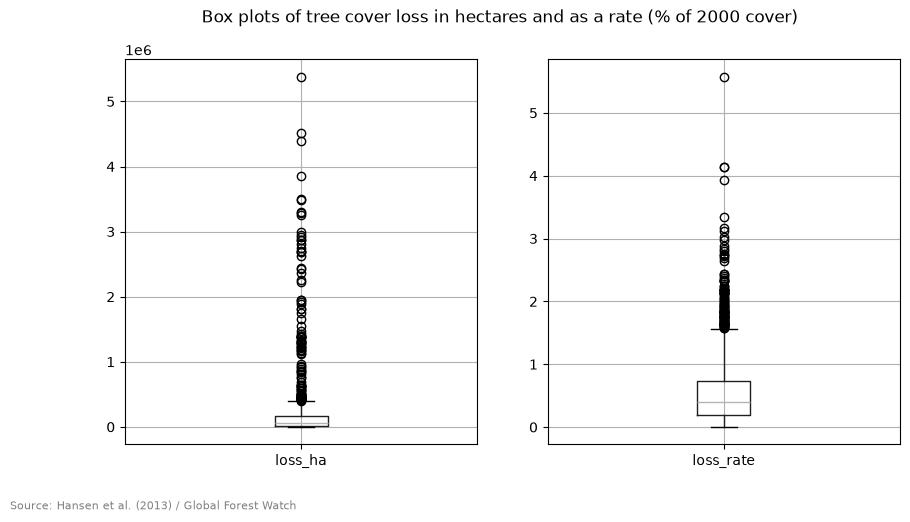

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
df_s.boxplot('loss_ha', ax=ax[0])
df_s.boxplot('loss_rate', ax=ax[1])
plt.suptitle('Box plots of tree cover loss in hectares and as a rate (% of 2000 cover)')
plt.figtext(0.01, -0.02, 'Source: Hansen et al. (2013) / Global Forest Watch', fontsize=8, color='grey')
plt.show()

### 3.4 Skewness and log transformation

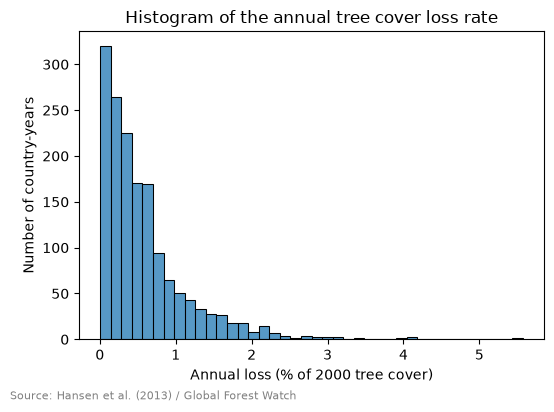

The skewness is: 2.256


In [27]:
def histogram_skewness(df, col, title, xlabel):
    '''Plot a histogram of the column "col" of "df" and print its skewness.'''
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=40)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Number of country-years')
    plt.figtext(0.01, -0.04, 'Source: Hansen et al. (2013) / Global Forest Watch', fontsize=8, color='grey')
    plt.show()
    print(f'The skewness is: {df[col].skew():0.3f}')

histogram_skewness(df_s, 'loss_rate', 'Histogram of the annual tree cover loss rate',
                   'Annual loss (% of 2000 tree cover)')

In [28]:
# How many country-years have zero loss?
n_zero = (df_s['loss_rate'] == 0).sum()
print("Country-years with zero loss:", n_zero)
print(df_s.loc[df_s['loss_rate'] == 0, 'country'].unique())

Country-years with zero loss: 0
<StringArray>
[]
Length: 0, dtype: str


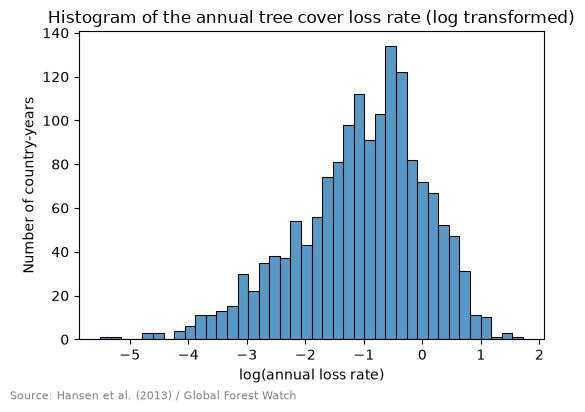

The skewness is: -0.600


In [29]:
# Log of the loss rate: possible because there is no zero loss in the sample (see above)
# asinh is not used: most rates are below 1%, where asinh(x) is almost equal to x and barely reduces the skewness
df_s['log_loss_rate'] = np.log(df_s['loss_rate'])

histogram_skewness(df_s, 'log_loss_rate',
                   'Histogram of the annual tree cover loss rate (log transformed)',
                   'log(annual loss rate)')

### Interpretation

#### Definition

Our outcome is the annual tree cover loss rate, defined as the area of tree cover lost in a given year
divided by the country's tree cover in 2000, expressed in percent:

$$\text{loss rate}_{i,t} = 100 \times \frac{\text{tree cover loss}_{i,t}}{\text{tree cover}_{i,2000}}$$

A value of 1.2 means that country *i* lost 1.2% of its 2000 tree cover during year *t*.

#### Why a rate, and why the 2000 tree cover

We use a rate rather than hectares for two reasons:

1. **Comparability across countries.** In hectares, Brazil alone loses more forest each year than most
   countries of our sample combined, simply because it is very large. Without normalisation, our analysis
   would mostly capture that large forested countries lose more forest, which is not informative.
2. **A denominator that is not affected by the treatment.** The 2000 tree cover is the baseline of the
   Hansen et al. (2013) dataset and is measured before our study period. It therefore cannot be influenced
   by commodity booms. Dividing by the previous year's cover instead would bias the outcome: a country that
   cleared a lot of forest in the past would mechanically show a higher rate later, so the outcome would be
   contaminated by the treatment itself.

Our sanity checks confirm that annual rates lie between 0.004 and 5.6%, and that cumulative loss over
2001 to 2025 never exceeds 100% of the 2000 cover. The countries with the highest cumulative loss are
Sierra Leone (40.5%), Cambodia (33.8%) and Malaysia (33.2%). These countries have very different profiles:
in Sierra Leone, a large part of the loss comes from shifting cultivation, while in Malaysia it also includes
the harvest and replanting of plantations (oil palm, timber), which the Hansen et al. (2013) data also count
as tree cover loss. Our outcome therefore measures gross tree cover loss, not only permanent deforestation,
a limit we come back to in step 5.

#### Distribution and transformation

The loss rate is highly right-skewed (skewness of 2.26): most countries lose less than 1% of their
forest per year, while a few experience much higher rates. A highly skewed outcome gives a large weight to
a few extreme observations in a regression, which makes the results fragile. Our skewness (2.26) is below
the rule of thumb of 3 used in the course, but above 1, the threshold commonly used to define a highly
skewed distribution. Since the log brings the distribution close to symmetry (see below), we apply it. Taking
the log of the deforestation rate is also common in the literature.

We use a log transformation. The logarithm is undefined at zero, and a zero loss would be a genuine
observation (no forest was lost that year) that we could not drop without bias. However, our sample contains
no country-year with zero loss (the lowest annual rate is 0.004%), so the log is defined for every observation.

We considered the inverse hyperbolic sine (asinh), often used when an outcome contains zeros. It is not
suitable here: asinh behaves like a logarithm only for large values, while 83% of our annual rates are below
1%, a range where asinh(x) is almost equal to x. It only reduces the skewness from 2.26 to 1.15, against
-0.60 for the log. Its results would also depend on the unit of the rate, which is arbitrary. The log has a
further advantage for interpretation: a coefficient $\beta$ corresponds approximately to a $100 \times \beta$ %
change in the loss rate (exactly $100 \times (e^{\beta} - 1)$ %), the approximation being good for small
coefficients.

After the log transformation, the skewness is -0.60: the distribution is close to symmetric, with a slightly
longer left tail (countries and years with very low loss). We use the log of the loss rate as our main
outcome in the rest of the analysis. If zeros appear in a robustness check,
we would use a Poisson pseudo-maximum likelihood (PPML) model, which handles zeros without any transformation.

*Reference: Hansen, M. C., et al. (2013). High-resolution global maps of 21st-century forest cover change.
Science, 342(6160), 850-853.*

## 4. Data quality and extreme values

### 4.1 Missing values and panel balance

In [30]:
# Missing values in the sample
print(df_s.isna().sum())

# Number of years per country: all countries should have 25
print(df_s.groupby('iso3')['year'].count().value_counts())

iso3              0
country           0
year              0
extent_2000_ha    0
loss_ha           0
share_tropics     0
region            0
loss_rate         0
log_loss_rate     0
dtype: int64
year
25    63
Name: count, dtype: int64


### 4.2 Highest loss rates

In [31]:
# The 10 country-years with the highest loss rate
df_s.nlargest(10, 'loss_rate')[['country', 'year', 'loss_rate', 'loss_ha']]

,country,year,loss_rate,loss_ha
69,Australia,2020,5.573410,2356518
1264,Sierra Leone,2015,4.143236,232762
1266,Sierra Leone,2017,4.143075,232753
68,Australia,2019,3.929731,1661547
1267,Sierra Leone,2018,3.350339,188218
1265,Sierra Leone,2016,3.162884,177687
1268,Sierra Leone,2019,3.123367,175467
1262,Sierra Leone,2013,3.030983,170277
891,Madagascar,2017,2.977390,510357
1263,Sierra Leone,2014,2.874981,161513


In [32]:
# Ratio between each year's rate and the country's average rate
df_s['rate_vs_mean'] = df_s['loss_rate'] / df_s.groupby('iso3')['loss_rate'].transform('mean')

df_s.nlargest(10, 'rate_vs_mean')[['country', 'year', 'loss_rate', 'rate_vs_mean']]

,country,year,loss_rate,rate_vs_mean
673,Guyana,2024,0.565039,6.785881
69,Australia,2020,5.573410,6.135208
1494,Vanuatu,2020,0.333149,5.498267
1489,Vanuatu,2015,0.294289,4.856919
391,Cuba,2017,1.913363,4.362617
68,Australia,2019,3.929731,4.325847
148,Bolivia,2024,2.809352,4.300151
390,Cuba,2016,1.844589,4.205808
1358,Taiwan,2009,0.348479,3.946274
490,Fiji,2016,0.537916,3.782663


### 4.3 Loss rate over time in selected countries

In [33]:
countries = ['BRA', 'IDN', 'BOL', 'COD', 'PRY', 'MYS']
fig = px.line(df_s[df_s['iso3'].isin(countries)],
              x='year', y='loss_rate', color='country',
              title='Annual tree cover loss rate in selected countries',
              labels={'loss_rate': 'Annual loss (% of 2000 tree cover)', 'year': 'Year', 'country': 'Country'},
              template='plotly_white')
fig.add_annotation(text='Source: Hansen et al. (2013) / Global Forest Watch',
                   x=0, y=-0.15, xref='paper', yref='paper', showarrow=False, font=dict(size=10))
fig.show()

### Interpretation

#### Completeness

Our sample is a complete and balanced panel: each of the 63 countries is observed in every year from 2001
to 2025, and no value is missing. Each country therefore contributes the same number of observations to the
analysis.

#### Extreme values

The highest loss rates in the sample are Australia, 2020 (5.6%), Sierra Leone, 2015 (4.1%) and
Sierra Leone, 2017 (4.1%). The Australian values for 2019 and 2020 correspond to the "Black Summer"
bushfires, one of the most severe fire seasons on record. Sierra Leone appears seven times among the ten
highest values, between 2013 and 2019: its loss is persistently high rather than driven by a single event,
and mostly comes from shifting cultivation (see the drivers section). Since a 2% loss is common for some
countries and exceptional for others, we also compared each year to the country's own average. The largest
deviations are Guyana, 2024 (6.8 times the country's average) and Australia, 2020 (6.1 times).

The figure above shows the loss rate over time for six countries, chosen to cover the main soy and cattle
producers (Brazil, Paraguay, Bolivia), the main palm oil producers (Indonesia, Malaysia) and a country with
low exposure to our commodities (DR Congo). The largest peaks match well-documented events:

- **Bolivia, 2024**: the highest value of the figure (about 2.8%), during a record fire season driven by an
  extreme drought. A smaller peak appears in 2019, the year of the large Chiquitania fires. Since fire is
  commonly used to clear land for agriculture in Bolivia, these peaks combine natural and agricultural causes.
- **Brazil, 2016 to 2017 and 2024**: two peaks linked to droughts and fire seasons. Brazil's rate is low
  overall because its 2000 forest cover is very large, so even millions of hectares lost represent a small
  share.
- **Indonesia, 2016**: this peak likely includes part of the 2015 fires, recorded the following year in the
  satellite data.

The figure also reveals patterns directly relevant to our research question:

- **Paraguay** shows a sharp increase in 2007 and high rates until 2012, a period of massive clearing in the
  Chaco for cattle ranching, which coincides with the soy and beef price booms.
- **Brazil** shows a decrease from 2004 to 2012, although commodity prices were booming in 2007 to 2008 and
  2010 to 2012. This period corresponds to the Action Plan for the Prevention and Control of Deforestation in
  the Legal Amazon (PPCDAm, 2004) and the Soy Moratorium (2006). It illustrates a key confounder for our
  analysis: public policies may offset, or hide, the effect of prices.
- **Indonesia and Malaysia** both decline after 2016 to 2017, when moratoria on primary forests and peatlands,
  zero-deforestation commitments by palm oil companies and lower prices occurred at the same time.
- **DR Congo** increases slowly and steadily, without marked peaks, which is consistent with deforestation
  driven mostly by smallholder and shifting agriculture rather than by export commodities.

#### Decision

We keep all observations. The extreme values correspond to real events rather than data errors, and they
are part of the variation we want to explain: removing them would mean removing precisely the years in which
something happens. The log transformation already strongly reduces their weight. To check that our results do
not depend on a few observations, we will run a robustness check in which the loss rate is winsorised at the
99th percentile.

#### Limits of the measure

Tree cover loss is not exactly deforestation. It includes losses from wildfires and from the harvest of tree
plantations (for instance oil palm or timber), which may later regrow. This partly explains the high
cumulative loss of Malaysia. In addition, several series show a "saw-tooth" pattern from one year to the
next, which may partly reflect how losses are attributed to a given year in the satellite data. Global Forest
Watch also notes that its detection method has improved over time, so comparisons between early and recent
years should be made with care. Year fixed effects in our regressions absorb changes that are common to all
countries, and the use of lagged prices will reduce the sensitivity to the exact year of each loss.

Finally, the next section uses the drivers of tree cover loss provided by Global Forest Watch to isolate the
share of loss caused by agriculture, which is the channel our research question focuses on.

## 5. Drivers of tree cover loss

### 5.1 Load the drivers data

In [34]:
SHEET_DRV = 'Country drivers'
df_drv_raw = pd.read_excel(xls, sheet_name=SHEET_DRV)

print("Shape:", df_drv_raw.shape)
print(list(df_drv_raw.columns))
df_drv_raw.head(10)

Shape: (27231, 5)
['country', 'threshold', 'driver', 'year', 'tc_loss_ha']


,country,threshold,driver,year,tc_loss_ha
0,Afghanistan,30,Logging,2001,3
1,Afghanistan,30,Other natural disturbances,2001,2
2,Afghanistan,30,Permanent agriculture,2001,64
3,Afghanistan,30,Wildfire,2001,2
4,Afghanistan,30,Logging,2002,67
5,Afghanistan,30,Other natural disturbances,2002,3
6,Afghanistan,30,Permanent agriculture,2002,51
7,Afghanistan,30,Wildfire,2002,31
8,Afghanistan,30,Hard commodities,2003,0
9,Afghanistan,30,Logging,2003,88


In [35]:
# Which drivers are in the file?
driver_col = [c for c in df_drv_raw.columns if 'driver' in c.lower()][0]
print("Driver column:", driver_col)
print(df_drv_raw[driver_col].value_counts())

# Is there a canopy threshold column?
if 'threshold' in df_drv_raw.columns:
    print("Thresholds:", sorted(df_drv_raw['threshold'].unique()))

Driver column: driver
driver
Permanent agriculture           4639
Settlements & Infrastructure    4553
Other natural disturbances      4134
Logging                         3947
Hard commodities                3790
Wildfire                        3696
Shifting cultivation            2472
Name: count, dtype: int64
Thresholds: [np.int64(30)]


In [36]:
# The drivers sheet is already in long format: one row per country, driver and year
df_drv = df_drv_raw.rename(columns={'tc_loss_ha': 'loss_ha'})[['country', 'driver', 'year', 'loss_ha']]

# Same ISO3 codes as for the main sheet, then keep the countries of our sample
df_drv['iso3'] = df_drv['country'].map(iso_map)
df_drv = df_drv[df_drv['iso3'].isin(df_s['iso3'].unique())].reset_index(drop=True)

print("Countries:", df_drv['iso3'].nunique(), "| Years:", df_drv['year'].min(), "to", df_drv['year'].max())
df_drv.head()

Countries: 63 | Years: 2001 to 2025


,country,driver,year,loss_ha,iso3
0,Angola,Hard commodities,2001,226,AGO
1,Angola,Logging,2001,646,AGO
2,Angola,Other natural disturbances,2001,1672,AGO
3,Angola,Permanent agriculture,2001,57200,AGO
4,Angola,Settlements & Infrastructure,2001,1154,AGO


### 5.2 Group the drivers into categories

In [37]:
# Group the 7 drivers into broad categories
driver_groups = {
    'Permanent agriculture':        'Agriculture',            # commodity crops, pastures, plantations
    'Shifting cultivation':         'Shifting agriculture',   # smallholder rotational farming
    'Wildfire':                     'Fire',
    'Logging':                      'Forestry',
    'Hard commodities':             'Other',                  # mining and energy
    'Settlements & Infrastructure': 'Other',
    'Other natural disturbances':   'Other',                  # storms, floods, landslides...
}
df_drv['driver_group'] = df_drv['driver'].map(driver_groups)

print("Unmapped drivers:", df_drv.loc[df_drv['driver_group'].isna(), 'driver'].unique())   # must be empty

Unmapped drivers: <StringArray>
[]
Length: 0, dtype: str


### 5.3 Check the drivers against total loss

In [38]:
# One row per country-year, one column per driver group
df_drv_wide = (df_drv.pivot_table(index=['iso3', 'year'], columns='driver_group',
                                   values='loss_ha', aggfunc='sum', fill_value=0)
                     .reset_index())

# Compare the sum of all drivers with the total loss of the main sheet
groups = [c for c in df_drv_wide.columns if c not in ['iso3', 'year']]
check = df_drv_wide.merge(df_s[['iso3', 'year', 'loss_ha']], on=['iso3', 'year'])
check['ratio'] = check[groups].sum(axis=1) / check['loss_ha']
print(check['ratio'].describe())

count    1575.000000
mean        0.987238
std         0.027453
min         0.661290
25%         0.989054
50%         0.996193
75%         0.998773
max         0.999984
Name: ratio, dtype: float64


In [39]:
# Loss not attributed to any driver (small difference between total and sum of drivers)
df_drv_wide = df_drv_wide.merge(df_s[['iso3', 'year', 'loss_ha']], on=['iso3', 'year'])
df_drv_wide['Unclassified'] = (df_drv_wide['loss_ha'] - df_drv_wide[groups].sum(axis=1)).clip(lower=0)
df_drv_wide = df_drv_wide.drop(columns='loss_ha')

print("Share of unclassified loss in the sample: "
      f"{100 * df_drv_wide['Unclassified'].sum() / df_s['loss_ha'].sum():.2f}%")

Share of unclassified loss in the sample: 0.31%


### 5.4 Drivers by country

In [40]:
# Share of each driver in total tree cover loss over 2001-2025, by country
drivers = groups + ['Unclassified']
shares = df_drv_wide.groupby('iso3')[drivers].sum()
shares = shares.div(shares.sum(axis=1), axis=0) * 100
shares = shares.merge(df_s[['iso3', 'country']].drop_duplicates(), on='iso3')
shares = shares.sort_values('Agriculture')

# Long format for plotly: one row per country and driver
df_bar = shares.melt(id_vars=['iso3', 'country'], value_vars=drivers,
                     var_name='Driver', value_name='Share (%)')

fig = px.bar(df_bar, x='Share (%)', y='country', color='Driver', orientation='h',
             title='Drivers of tree cover loss by country, 2001 to 2025 (share of total loss)',
             labels={'country': ''},
             category_orders={'Driver': ['Agriculture', 'Shifting agriculture', 'Fire',
                                         'Forestry', 'Other', 'Unclassified']},
             template='plotly_white', height=1300)
n_countries = df_bar['country'].nunique()
fig.update_layout(height=22 * n_countries + 150, margin=dict(t=80, b=60))
fig.update_yaxes(dtick=1, tickfont=dict(size=10))          # show every country name
fig.update_xaxes(range=[0, 100], ticksuffix='%', title='Share of total tree cover loss')
fig.add_annotation(text='Source: Global Forest Watch, drivers of tree cover loss',
                   x=0, y=-0.02, xref='paper', yref='paper', showarrow=False, font=dict(size=10))
fig.show()

### 5.5 A second outcome: the agricultural loss rate

In [41]:
# Add agricultural loss to the main panel
df_s = df_s.merge(df_drv_wide[['iso3', 'year', 'Agriculture']].rename(columns={'Agriculture': 'agri_loss_ha'}),
                  on=['iso3', 'year'], how='left')

df_s['agri_loss_rate'] = 100 * df_s['agri_loss_ha'] / df_s['extent_2000_ha']

print("Country-years with zero agricultural loss:", (df_s['agri_loss_rate'] == 0).sum())
print("Missing values:", df_s['agri_loss_rate'].isna().sum())
df_s[['loss_rate', 'agri_loss_rate']].describe()

Country-years with zero agricultural loss: 0
Missing values: 0


,loss_rate,agri_loss_rate
count,1575.000000,1575.000000
mean,0.574885,0.326470
std,0.570810,0.366894
min,0.004064,0.000677
25%,0.185389,0.054199
50%,0.403488,0.217930
75%,0.737379,0.463700
max,5.573410,2.677535


Permanent agriculture accounts for 60.1% of tree cover loss in our sample


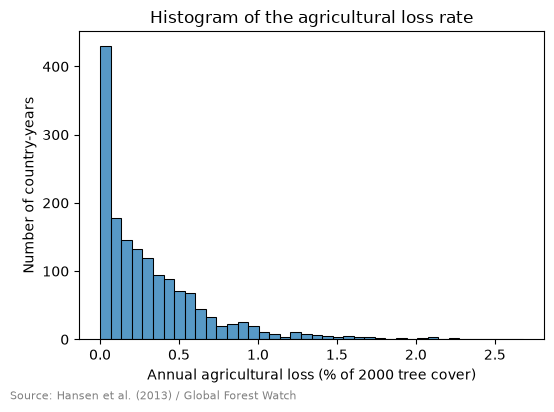

The skewness is: 2.108


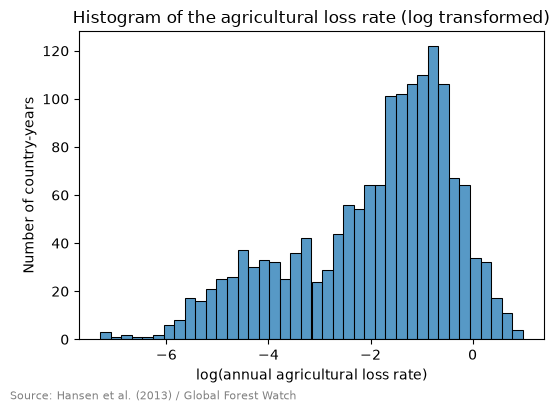

The skewness is: -0.780
Correlation between the two log outcomes: 0.83


In [42]:
# Share of agriculture in total loss over the whole sample (weighted by hectares)
share_agri = 100 * df_s['agri_loss_ha'].sum() / df_s['loss_ha'].sum()
print(f"Permanent agriculture accounts for {share_agri:.1f}% of tree cover loss in our sample")

# Same transformation as the main outcome
df_s['log_agri_loss_rate'] = np.log(df_s['agri_loss_rate'])

histogram_skewness(df_s, 'agri_loss_rate', 'Histogram of the agricultural loss rate',
                   'Annual agricultural loss (% of 2000 tree cover)')
histogram_skewness(df_s, 'log_agri_loss_rate', 'Histogram of the agricultural loss rate (log transformed)',
                   'log(annual agricultural loss rate)')

# How closely do the two outcomes move together?
print("Correlation between the two log outcomes:",
      round(df_s[['log_loss_rate', 'log_agri_loss_rate']].corr().iloc[0, 1], 2))

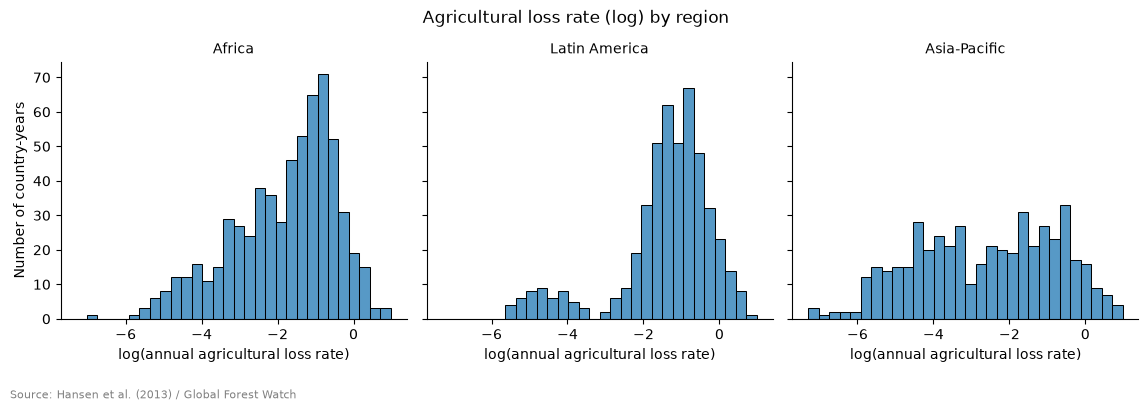

Within-country correlation between the two log outcomes: 0.87
country                region       
Fiji                   Asia-Pacific    -5.52
Vanuatu                Asia-Pacific    -5.24
Bhutan                 Asia-Pacific    -4.84
Suriname               Latin America   -4.56
Guyana                 Latin America   -4.54
Gabon                  Africa          -4.51
Nepal                  Asia-Pacific    -4.36
Solomon Islands        Asia-Pacific    -4.35
Republic of the Congo  Africa          -4.33
Papua New Guinea       Asia-Pacific    -3.90
Equatorial Guinea      Africa          -3.89
South Sudan            Africa          -3.80
Name: log_agri_loss_rate, dtype: float64


In [43]:
# 1. Distribution of the agricultural loss rate (log), one panel per region
g = sns.displot(data=df_s, x='log_agri_loss_rate', col='region', bins=30, height=3.5, aspect=1.1)
g.set_axis_labels('log(annual agricultural loss rate)', 'Number of country-years')
g.set_titles('{col_name}')
g.fig.suptitle('Agricultural loss rate (log) by region', y=1.05)
plt.figtext(0.01, -0.06, 'Source: Hansen et al. (2013) / Global Forest Watch', fontsize=8, color='grey')
plt.show()

# 2. Within-country correlation: remove each country's average, then correlate
within = df_s[['log_loss_rate', 'log_agri_loss_rate']] - df_s.groupby('iso3')[['log_loss_rate', 'log_agri_loss_rate']].transform('mean')
print("Within-country correlation between the two log outcomes:",
      round(within.corr().iloc[0, 1], 2))

# 3. Countries with the lowest average agricultural loss rate (log)
low = (df_s.groupby(['country', 'region'])['log_agri_loss_rate'].mean()
           .sort_values().head(12).round(2))
print(low)

### Interpretation

#### Why look at drivers

Our outcome so far includes all tree cover loss, whatever its cause: agricultural expansion, but also
wildfires, logging or the harvest of tree plantations. Our research question, however, focuses on
agricultural commodities. Global Forest Watch provides, for each country and year, the tree cover loss
attributed to seven drivers. We use this information for two purposes: to describe why forests are lost in
each country, and to build a second outcome restricted to agricultural loss.

We use the drivers of **total tree cover loss** rather than the drivers of primary forest loss, for
consistency with our main outcome. Primary forest data only cover humid tropical primary forests and would
leave out the dry forests of the Chaco (Argentina, Paraguay) and of Bolivia, which are major frontiers for
soy and cattle. Primary forest loss will instead be used as a robustness check for the subset of countries
that have such forests.

#### Grouping the drivers

We group the seven drivers into five categories:

| Driver in the data | Category |
|---|---|
| Permanent agriculture (crops, pastures, tree crops) | **Agriculture** |
| Shifting cultivation | Shifting agriculture |
| Wildfire | Fire |
| Logging | Forestry |
| Hard commodities (mining, energy), settlements and infrastructure, other natural disturbances | Other |

We keep shifting cultivation separate from permanent agriculture. It is mostly practised by smallholders who
grow food for their own consumption and let the forest regrow afterwards, so it is unlikely to respond to
world prices of soy, palm oil or beef. Pooling it with permanent agriculture would dilute the effect we want
to measure. We will include it in a robustness check.

#### Consistency check

For each country-year, the sum of all drivers matches the total tree cover loss of the main dataset very
closely: the median ratio is 0.996 and the ratio never exceeds 1. Overall, 0.31% of the loss in our sample is
not attributed to any driver; we report it as "Unclassified".

#### What the drivers show

Permanent agriculture accounts for **60.1% of tree cover loss** in our sample of 63 tropical countries
over 2001 to 2025, which confirms that agriculture is the main driver of tropical forest loss. This share,
however, varies enormously across countries, from more than 90% in Cambodia, Côte d'Ivoire and Paraguay to
about 3% in Australia and Fiji (figure above):

- **Agriculture dominates** in the main soy and cattle producers (Paraguay, Argentina, Brazil, Mexico and
  Central America) and in the main palm oil producers (Malaysia, Indonesia), where it accounts for about 70% to
  93% of the loss.
- **Bolivia** combines agriculture (about 55%) with a large share of fires (37%), consistent with
  the 2024 peak observed earlier. Since fire is often used to clear land for agriculture in Bolivia, part of
  this loss may have an agricultural origin.
- **Shifting agriculture dominates** in Central and West Africa (DR Congo, Republic of the Congo, Guinea,
  Liberia, Sierra Leone) and in Madagascar. In Sierra Leone it accounts for 80% of the loss, which explains
  its record cumulative loss.
- **Logging** dominates where tree plantations are harvested (South Africa, Fiji, Solomon Islands), **fires**
  dominate in Australia, and the **"Other" category**, likely gold mining, is large in Guyana and Suriname.

At the regional level, agriculture accounts for 73.6% of the loss in Latin America, 54.5% in Asia-Pacific and
41.4% in Africa.

This variation is precisely what our identification strategy relies on: countries are very unequally exposed
to the agricultural channel, and therefore to commodity price shocks.

One limitation must be kept in mind: "permanent agriculture" covers all permanent crops and pastures, not
only our three commodities. Côte d'Ivoire and Ghana, for instance, rank among the countries with the highest
agricultural share, mostly because of cocoa. Our exposure measure (world price times crop suitability) will
isolate the channel of each commodity.

#### A second outcome: the agricultural loss rate

We build an agricultural loss rate in the same way as the total loss rate, dividing agricultural loss by
the fixed tree cover in 2000. It contains no zero, so we apply the same log transformation, which reduces
the skewness from 2.11 to -0.78. Its distribution differs across regions: Latin America is concentrated at
high values, apart from Guyana and Suriname, while Asia-Pacific and Africa include several "high forest, low
deforestation" countries (Fiji, Vanuatu, Bhutan, Papua New Guinea, Gabon, Republic of the Congo) with very
low agricultural loss.

The two outcomes are highly correlated (0.83), including within countries over time (0.87), which is the
variation exploited by a regression with country fixed effects. Year-to-year changes in tree cover loss in
our sample are therefore largely changes in agricultural clearing, which supports the use of total loss as
our main outcome. The agricultural loss rate will serve as a **mechanism test**: if commodity booms increase
agricultural loss but not loss from fires or logging, this will support the interpretation that their
effect operates through agricultural expansion.

## 6. Univariate summary of deforestation

### 6.1 Descriptive statistics by region

In [44]:
# Descriptive statistics of the loss rate by region
summary = (df_s.groupby('region')
               .agg(countries=('iso3', 'nunique'),
                    mean_rate=('loss_rate', 'mean'),
                    median_rate=('loss_rate', 'median'),
                    sd_rate=('loss_rate', 'std'),
                    total_loss_Mha=('loss_ha', lambda x: x.sum() / 1e6),
                    agri_loss_Mha=('agri_loss_ha', lambda x: x.sum() / 1e6)))
summary['agri_share_%'] = 100 * summary['agri_loss_Mha'] / summary['total_loss_Mha']
summary.round(2)

,countries,mean_rate,median_rate,sd_rate,total_loss_Mha,agri_loss_Mha,agri_share_%
region,,,,,,,
Africa,25,0.65,0.47,0.64,69.13,28.65,41.45
Asia-Pacific,19,0.52,0.33,0.58,80.04,43.60,54.48
Latin America,19,0.53,0.41,0.45,129.08,94.95,73.56


### 6.2 Map of the average loss rate

In [45]:
# Average annual loss rate per country over 2001-2025
df_map = df_s.groupby(['iso3', 'country'])['loss_rate'].mean().reset_index()

fig = px.choropleth(df_map,
                    locations='iso3',
                    locationmode='ISO-3',
                    color='loss_rate',
                    hover_name='country',
                    color_continuous_scale='YlOrRd',
                    labels={'loss_rate': 'Average annual<br>loss rate (%)'},
                    title='Average annual tree cover loss rate, 2001 to 2025',
                    template='plotly_white')
fig.update_geos(lataxis_range=[-45, 45], showcountries=True)
fig.add_annotation(text='Source: Hansen et al. (2013) / Global Forest Watch',
                   x=0, y=-0.08, xref='paper', yref='paper', showarrow=False, font=dict(size=10))
fig.show()

### 6.3 Trends by region

In [46]:
# Regional loss rate per year: total loss / total 2000 cover (weighted by forest size)
trend = (df_s.groupby(['region', 'year'])[['loss_ha', 'agri_loss_ha', 'extent_2000_ha']].sum()
             .reset_index())
trend['Total loss'] = 100 * trend['loss_ha'] / trend['extent_2000_ha']
trend['Agricultural loss'] = 100 * trend['agri_loss_ha'] / trend['extent_2000_ha']

df_trend = trend.melt(id_vars=['region', 'year'], value_vars=['Total loss', 'Agricultural loss'],
                      var_name='Measure', value_name='Loss rate (%)')

fig = px.line(df_trend, x='year', y='Loss rate (%)', color='region', line_dash='Measure',
              title='Annual tree cover loss rate by region (total and agricultural)',
              labels={'year': 'Year', 'region': 'Region'}, template='plotly_white')
fig.add_annotation(text='Source: Hansen et al. (2013) / Global Forest Watch',
                   x=0, y=-0.15, xref='paper', yref='paper', showarrow=False, font=dict(size=10))
fig.show()

### Interpretation

**Regional summary.** Our 63 countries lost about 278 Mha of tree cover over 2001 to 2025: 129 Mha in Latin
America, 80 Mha in Asia-Pacific and 69 Mha in Africa. The share of permanent agriculture in this loss is
highest in Latin America (73.6%), followed by Asia-Pacific (54.5%) and Africa (41.4%). The average annual
loss rate is highest in Africa (0.65% per country and year, against 0.52% to 0.53% in the two other regions),
which shows that some African countries lose a large share of their forest even though the region loses
fewer hectares.

**Geographical patterns.** The map shows that the highest average loss rates are found in West Africa
(Sierra Leone 1.6% per year, Guinea, Liberia, Côte d'Ivoire), in mainland Southeast Asia and Malaysia
(Cambodia 1.4%, Malaysia 1.3%, Laos), in Madagascar and in Paraguay (1.2%). At the other end, the lowest rates
(below 0.15% per year) are found in "high forest, low deforestation" countries such as Guyana, Suriname and
Gabon, in mountain countries (Nepal, Bhutan) and in some Pacific islands. Brazil appears relatively light on
the map despite being the country that loses the most hectares, because its 2000 forest cover is very large.

**Trends over time.** The three regions follow different paths (regional rates weighted by forest size):

- **Africa** shows a steady increase: its total loss rate tripled, from 0.22% per year in 2001 to 2005 to
  0.66% in 2021 to 2025. Agricultural loss also increased (from 0.10% to 0.27%), but it explains less than
  half of the total, the rest coming mostly from shifting agriculture.
- **Asia-Pacific** shows several peaks (2009, 2012, 2014, 2016) and its highest rate in 2016 (1.18%).
  Agricultural loss peaked in 2012 (0.63%) and then declined to about 0.30% in the 2020s, consistent with the
  decline observed in Indonesia and Malaysia. The high total rates of 2019 and 2020 are not agricultural: they
  are driven by the Australian bushfires.
- **Latin America** has the most stable total rate, around 0.4% to 0.5% per year, with peaks in fire years
  (2016 to 2017 and 2024). Its agricultural loss rate decreased over the period (from 0.42% in 2001 to 2005 to
  0.34% in 2021 to 2025), with a peak in 2004 followed by a decline that coincides with the new deforestation
  policies in Brazil.

**What this means for our analysis.** Three lessons emerge from this univariate exploration. First, the gap
between total and agricultural loss varies across regions and years, mostly because of fires and shifting
agriculture: comparing the two outcomes will help isolate the agricultural channel. Second, some peaks in
agricultural loss, such as Asia-Pacific in 2012, coincide with periods of high commodity prices, while others
do not, as in Latin America after 2004, where policies seem to dominate. Whether commodity booms actually drive
deforestation, once these other factors are taken into account, is the question of the bivariate analysis,
in which we will combine these data with world commodity prices and the agro-climatic suitability of each
country.

## 7. Appendix: numbers quoted in the text

In [47]:
# Summary of all the numbers quoted in the markdown cells
print("=== Sample (step 3) ===")
print(f"All countries: {n_all} | tropical band: {n_tropics} | + forest: {n_forest} | final: {n_final}")
print(f"Observations: {len(df_s)} ({n_final} countries x {df_s['year'].nunique()} years)")
print(df_s.groupby('region')['iso3'].nunique())

print("\n=== Outcome (step 4) ===")
print(f"Loss rate: min {df_s['loss_rate'].min():.3f}% | max {df_s['loss_rate'].max():.2f}%")
print("Top 3 cumulative loss (% of 2000 cover):")
print(df_s.groupby('country')['loss_rate'].sum().nlargest(3).round(1))
print(f"Skewness: raw {df_s['loss_rate'].skew():.2f} | log {df_s['log_loss_rate'].skew():.2f}")
print(f"Zeros: {(df_s['loss_rate'] == 0).sum()}")

print("\n=== Drivers (step 6) ===")
print(f"Agriculture share: {100 * df_s['agri_loss_ha'].sum() / df_s['loss_ha'].sum():.1f}%")
print(f"Unclassified share: {100 * df_drv_wide['Unclassified'].sum() / df_s['loss_ha'].sum():.2f}%")
print(f"Agri skewness: raw {df_s['agri_loss_rate'].skew():.2f} | log {df_s['log_agri_loss_rate'].skew():.2f}")
cols = ['log_loss_rate', 'log_agri_loss_rate']
within = df_s[cols] - df_s.groupby('iso3')[cols].transform('mean')
print(f"Correlation: overall {df_s[cols].corr().iloc[0, 1]:.2f} | within {within.corr().iloc[0, 1]:.2f}")

=== Sample (step 3) ===
All countries: 224 | tropical band: 135 | + forest: 66 | final: 63
Observations: 1575 (63 countries x 25 years)
region
Africa           25
Asia-Pacific     19
Latin America    19
Name: iso3, dtype: int64

=== Outcome (step 4) ===
Loss rate: min 0.004% | max 5.57%
Top 3 cumulative loss (% of 2000 cover):
country
Sierra Leone    40.5
Cambodia        33.8
Malaysia        33.2
Name: loss_rate, dtype: float64
Skewness: raw 2.26 | log -0.60
Zeros: 0

=== Drivers (step 6) ===
Agriculture share: 60.1%
Unclassified share: 0.31%
Agri skewness: raw 2.11 | log -0.78
Correlation: overall 0.83 | within 0.87
